## 1. Persiapan Pustaka dan Unduh Data
Langkah pertama adalah menginstal pustaka yang dibutuhkan dan memuat dataset **Electricity Demand** di Victoria, Australia. Karena data aslinya dicatat per setengah jam, kita melakukan agregasi (resampling) menjadi frekuensi harian. Total permintaan listrik dijumlahkan (`sum`), sedangkan suhu udaranya dirata-ratakan (`mean`).

In [ ]:
!pip install skforecast shap lightgbm

import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Download data
data = fetch_dataset(name="vic_electricity")

# Aggregation to daily frequency
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
display(data.head(3))

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


## 2. Pembuatan dan Pelatihan Model Prediksi
Data dibagi menjadi data latih (sebelum 22 Des 2014) dan data uji. Selanjutnya, kita membangun model peramalan menggunakan `ForecasterRecursive` dengan algoritma dasar `LGBMRegressor` (LightGBM). Model ini dilatih untuk memprediksi konsumsi listrik menggunakan memori 7 hari ke belakang (`lags = 7`) dan 1 variabel eksogen, yaitu Suhu Udara (`Temperature`).

In [ ]:
# Split train-test
data_train = data.loc[: '2014-12-21']
data_test  = data.loc['2014-12-22':]

# Create a recursive multi-step forecaster
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
display(forecaster)

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 01:32:43 
Last fit date: 2026-06-11 01:32:43 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

## 3. Tingkat Kepentingan Fitur (Feature Importance) Bawaan Model
Sebelum menggunakan metode tingkat lanjut, kita bisa mengekstrak bobot bawaan dari model LightGBM untuk melihat secara kasar fitur mana yang paling relevan dalam membuat prediksi.

In [ ]:
# Predictors importances
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## 4. Persiapan Matriks Data dan SHAP Explainer
Karena model ensemble bertindak sebagai "kotak hitam", kita menggunakan nilai SHAP untuk memahami dampaknya. Langkah pertama adalah menyiapkan matriks *training* dan membuat *TreeExplainer*.

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )
display(X_train.head(3))
display(y_train.head(3))

# Create SHAP explainer
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


## 5. Interpretasi Global dengan SHAP Summary Plot
*Summary Plot* di bawah ini menunjukkan secara global bagaimana setiap fitur memengaruhi prediksi. Warna merepresentasikan nilai fitur (merah = tinggi, biru = rendah), dan posisinya di sumbu X menunjukkan dorongannya terhadap prediksi listrik.

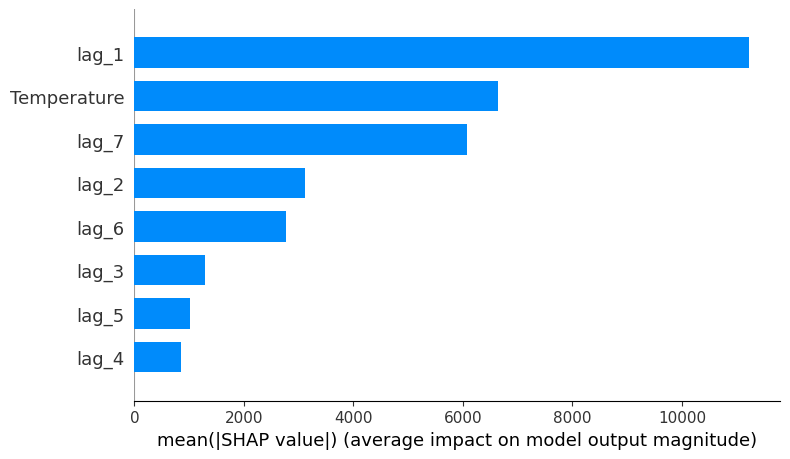

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

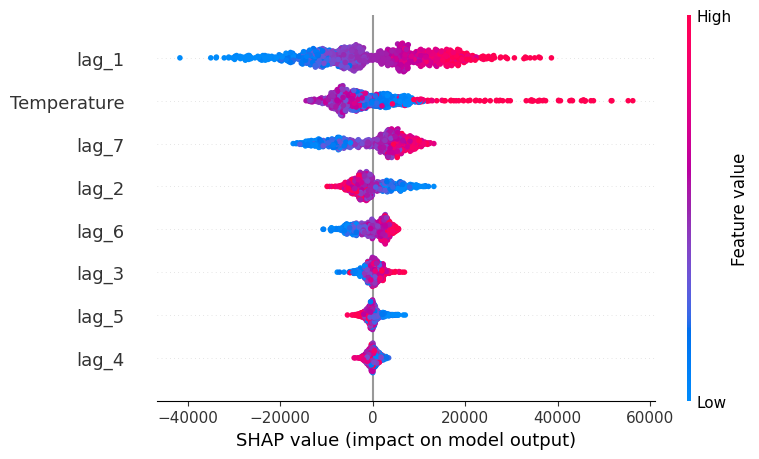

In [ ]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_train)


## 6. Visualisasi Interaktif 200 Observasi
Untuk melihat perubahan pola dari hari ke hari, kita menumpuk ratusan *force plot* individual dari 200 data pertama dan memutarnya 90 derajat. *(Plot ini interaktif dan membutuhkan JavaScript)*.

In [ ]:
# Force plot for the first 200 observations in the training set
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

## 7. Analisis Prediksi Satu Hari (Local Explainability)
SHAP juga bisa membedah alasan model pada **satu hari tertentu**. *Force plot* di bawah ini dibuat statis dan menunjukkan secara presisi berapa dorongan (dalam Megawatt) dari masing-masing fitur terhadap hasil akhir prediksi pada observasi pertama di data latih.

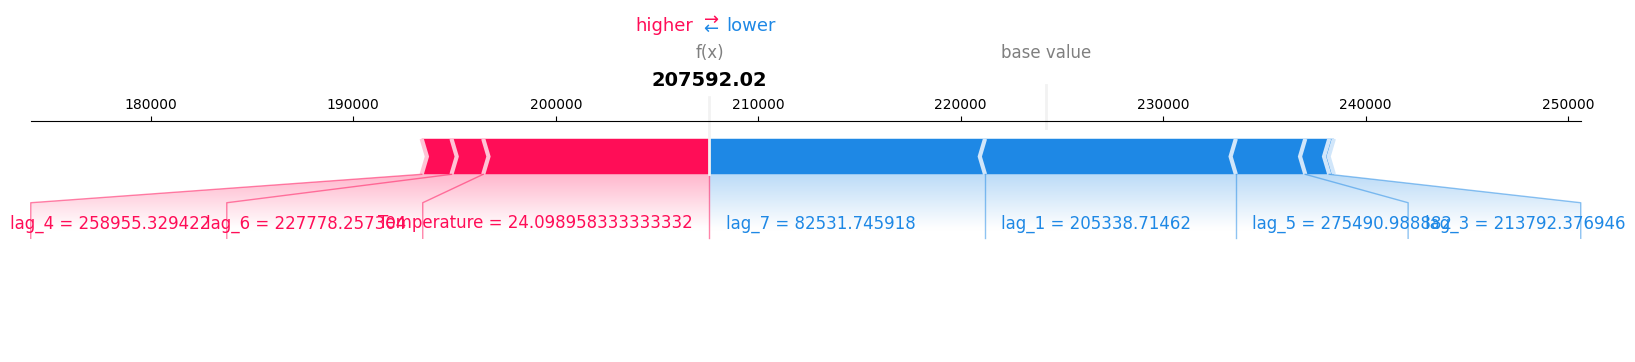

In [ ]:
# Force plot for the first observation (Statis)
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :],
    matplotlib=True
)

## 8. SHAP Dependence Plot
Plot ini difokuskan pada satu fitur, yaitu Suhu (`Temperature`), untuk melihat korelasi detail antara perubahan suhu udara dengan nilai SHAP (dampaknya terhadap prediksi listrik).

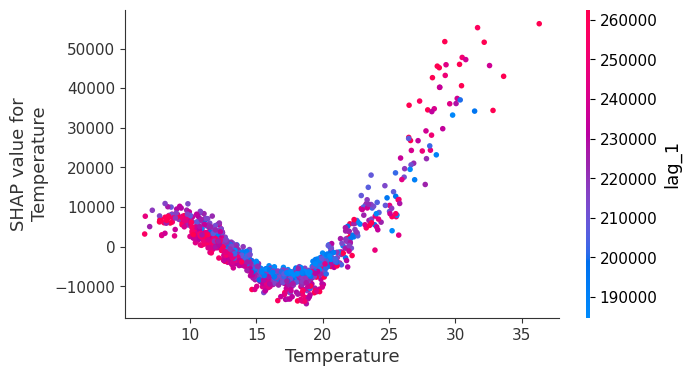

In [ ]:
# Dependence plot for Temperature
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

## 9. Interpretasi Nilai Prediksi Masa Depan (Forecasting)
Model digunakan untuk memprediksi 10 hari ke depan. Kita juga menyiapkan matriks inputnya (`X_predict`) untuk melihat alasan model saat memprediksi permintaan listrik spesifik pada tanggal **22 Desember 2014**.

In [ ]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


In [ ]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


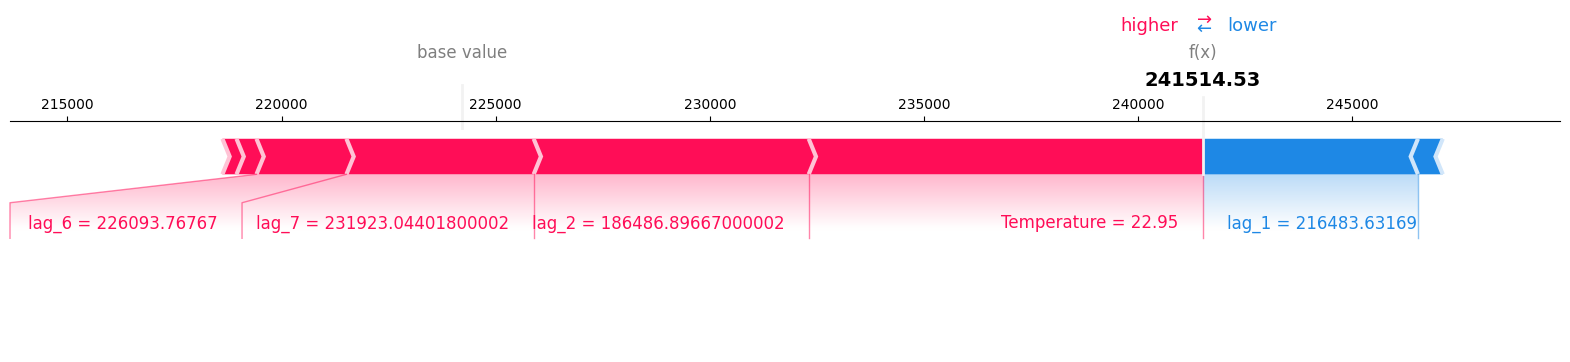

In [ ]:

# Force plot for a specific prediction (2014-12-22)
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values_pred = explainer.shap_values(X_predict)

shap.force_plot(
    explainer.expected_value,
    shap_values_pred[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :],
    matplotlib=True
)

## 10. Permutation Feature Importance
Metode ini menguji seberapa penting sebuah fitur dengan cara mengacak (*shuffle*) nilai salah satu kolom. Semakin hancur akurasi model setelah kolom tersebut diacak, berarti kolom tersebut semakin penting.

In [ ]:
# Permutation importances
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)

display(importances)

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## 11. Partial Dependence Plots (PDP)
Terakhir, kita memvisualisasikan efek marginal dari `Temperature` dan `lag_1`. Grafik ini menunjukkan bagaimana perubahan pada fitur tersebut memengaruhi prediksi secara rata-rata, dengan mengasumsikan fitur lainnya tetap konstan.

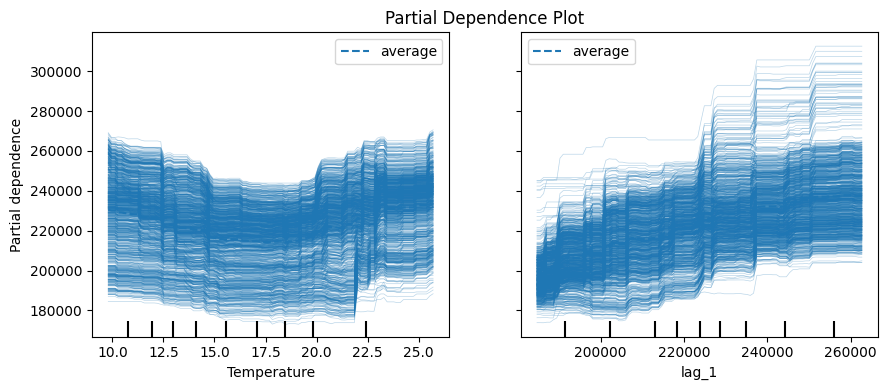

In [ ]:
# Scikit-learn partial dependence plots
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")

pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)

ax.set_title("Partial Dependence Plot")
fig.tight_layout();

# Lembar Jawaban Tugas Model Explainability
**Fahdimas Akmal - 240411100228**

**1. Analisa prediksi tentang apa?**
Analisis ini berfokus pada prediksi (peramalan) **Permintaan Listrik Harian (Electricity Demand)** di kota Melbourne (Victoria), Australia. Tujuan utama dari praktikum ini adalah untuk menerapkan **Model Explainability (Keterjelasan Model)**. Alih-alih hanya mendapatkan angka prediksi, kita membedah kotak hitam (*black-box*) model untuk memahami *mengapa* model memprediksi angka tersebut, serta seberapa besar dorongan faktor cuaca (suhu) dan riwayat listrik sebelumnya terhadap hasil akhir.

**2. Bagaimana bentuk data trainingnya (apa saja inputnya dan apa outputnya)?**
Data asli dari deret waktu diubah (*windowing*) menjadi matriks tabular (*supervised learning*).
* **Input (X_train):** Terdiri dari 8 fitur, yaitu **7 variabel Lags** (`lag_1` sampai `lag_7` yang mewakili memori konsumsi listrik 7 hari sebelumnya) dan **1 variabel Eksogen** (Suhu Udara / `Temperature` pada hari yang dituju).
* **Output (y_train):** Kolom target tunggal yang berisi angka aktual permintaan listrik (`Demand`) pada hari yang akan diprediksi.

**3. Apa itu Lag?**
Dalam analisis deret waktu (*time series*), **Lag** adalah nilai observasi dari kejadian di masa lalu yang dijadikan sebagai variabel prediktor untuk masa depan. Karena model regresi *machine learning* biasa tidak bisa memahami urutan waktu, memori waktu diubah menjadi kolom data (*lag*). Jika targetnya adalah konsumsi listrik hari ini (hari ke-t), maka konsumsi listrik kemarin adalah `lag_1` (t-1), dua hari lalu adalah `lag_2` (t-2), dan seterusnya.

**4. Jelaskan proses analysis yang dilakukan dari kasus di atas!**
Alur analisis yang dilakukan secara berurutan adalah:
1. **Data Preparation:** Data deret waktu diunduh, diagregasi menjadi nilai harian, dan displit menjadi matriks `X_train` dan `y_train`.
2. **Modeling:** Model LightGBM `ForecasterRecursive` dilatih menggunakan *lags* dan data suhu udara.
3. **Global Explainability:** Model diekstraksi bobot bawaannya, lalu dianalisis menggunakan **SHAP Summary Plot** untuk mencari tahu fitur mana yang secara keseluruhan paling mendominasi arah prediksi (Suhu dan *Lag_1*).
4. **Local Explainability:** Menggunakan **SHAP Force Plot** pada data pelatihan maupun data peramalan untuk membedah secara presisi (dalam MW) nilai fitur mana yang mendorong prediksi naik ke arah merah, dan mana yang menahannya turun ke arah biru.
5. **Validasi:** Menggunakan **Permutation Importance** dan **Partial Dependence Plot** untuk memvalidasi dan memvisualisasikan lebih lanjut seberapa besar kebergantungan model terhadap perubahan suhu dan histori listrik.